# Workshop 4: Space Spin-off Technologies and Innovation
## From Missile Guidance to Your Pocket: The GPS Story

**NPSC2002 - Space Exploration: Science, Technology and Industry**

---

The Global Positioning System (GPS) signal reaching your phone right now was
designed in the Pentagon during the Cold War to guide Polaris
submarine-launched ballistic missiles. This workshop traces the full journey:
from deterrence strategy to the everyday technologies GPS made possible, through
to the 2017 incidents that showed just how dangerous our dependency has become.

**A note on Selective Availability (SA):** Throughout this workshop you will
encounter SA, a deliberate policy decision that degraded GPS accuracy for
civilian users from roughly 10 metres to roughly 100 metres CEP. SA was
activated in 1990 and disabled on 1 May 2000. Understanding why it existed,
who it affected, and why it was eventually switched off is a central theme of
this workshop.

### Workshop Structure

| Section | Topic | Mode |
|-----|-------|------|
| 1 | Cold War Origins (1957-1973) | Literature research |
| 2 | The Civilian Revolution | Data + spin-off research |
| 3 | Selective Availability: Precision as Policy | Simulation + research |
| 4 | Spoofing and Jamming: The Dark Side | Simulation + research |
| 5 | Economic Legacy and Geopolitics | Literature research |

**Save frequently** (Ctrl+S). Completion is verified by timestamp.
Answer cells are marked with a pencil emoji. Scientific reasoning earns marks, not coding.
All code is pre-written; your job is to interpret results and answer questions.

In [1]:
# Run this cell first before anything else
!pip install skyfield -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import pandas as pd
from datetime import datetime, timezone
import requests
import warnings
warnings.filterwarnings('ignore')

from skyfield.api import load, EarthSatellite, wgs84

# Course dark theme
plt.rcParams.update({
    'figure.facecolor':  '#0a0e1a',
    'axes.facecolor':    '#0a0e1a',
    'axes.edgecolor':    '#c9a84c',
    'text.color':        '#e8e8e8',
    'axes.labelcolor':   '#e8e8e8',
    'xtick.color':       '#e8e8e8',
    'ytick.color':       '#e8e8e8',
    'grid.color':        '#1e2840',
    'grid.alpha':        0.5,
    'axes.titlecolor':   '#c9a84c',
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

GOLD   = '#c9a84c'
BLUE   = '#4a9eff'
RED    = '#ff6b6b'
GREEN  = '#51cf66'
PURPLE = '#cc5de8'
TEAL   = '#38d9a9'
BG     = '#0a0e1a'
PANEL  = '#111827'

print("Setup complete.")
print(f"UTC time: {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S')} UTC")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 5.2 MB/s eta 0:00:00
Setup complete.
UTC time: 2026-03-09 04:07:06 UTC


---
# Section 1: Cold War Origins (1957-1973)

The story of GPS begins not with navigation, but with nuclear deterrence.

On 4 October 1957, the Soviet Union launched Sputnik 1. Two physicists at
Johns Hopkins APL, William Guier and George Weiffenbach, were listening to
its radio beacon from their lab. They realised they could determine the
satellite's precise orbit by measuring the Doppler shift of its signal. Their
supervisor, Frank McClure, immediately saw the inverse possibility: if you can
track a satellite from the ground, a satellite can locate a receiver on the
ground.

By 1960, the U.S. Navy had a working satellite navigation system, TRANSIT,
operational for Polaris ballistic missile submarines. But TRANSIT could only
provide a position fix once every 90 minutes. The military needed continuous,
global, real-time positioning, accurate enough to guide weapons. In 1973 the
Department of Defense consolidated three competing navigation programs into a
single system: NAVSTAR GPS (Navigation System using Timing and Ranging, Global
Positioning System), under Air Force Colonel Bradford Parkinson.

Run the timeline below, then answer the research questions.

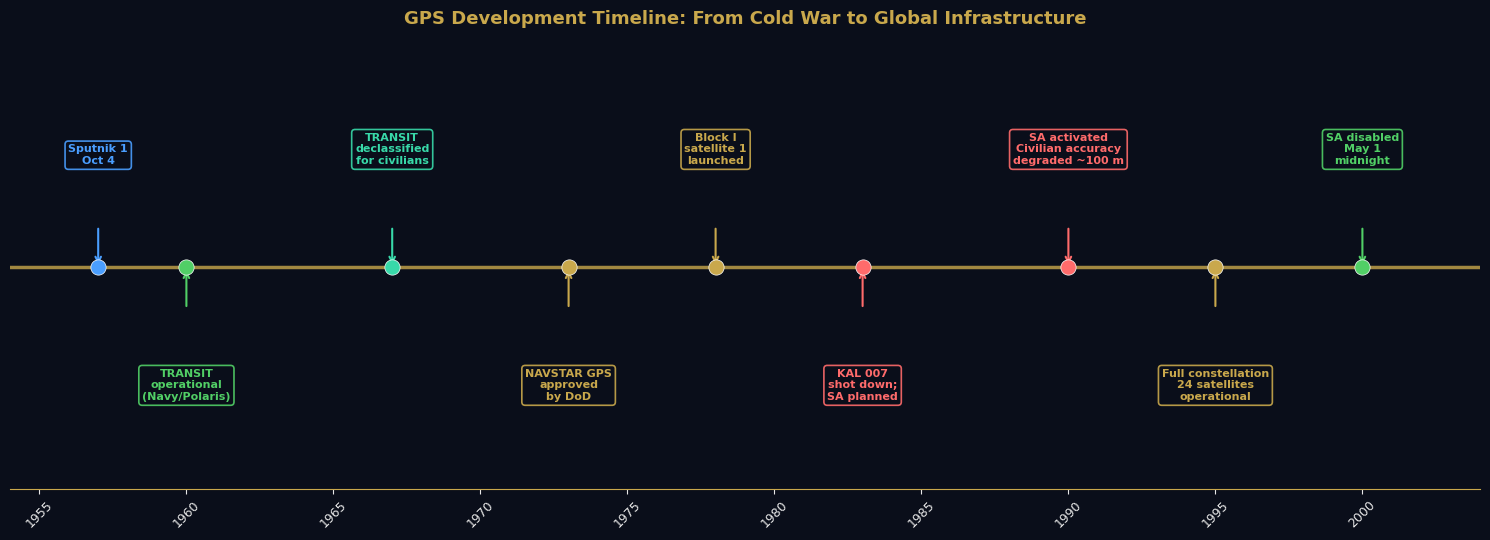

In [2]:
# GPS Development Timeline
fig, ax = plt.subplots(figsize=(15, 5.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

events = [
    (1957, "Sputnik 1\nOct 4",                    BLUE,   1),
    (1960, "TRANSIT\noperational\n(Navy/Polaris)", GREEN, -1),
    (1967, "TRANSIT\ndeclassified\nfor civilians", TEAL,   1),
    (1973, "NAVSTAR GPS\napproved\nby DoD",        GOLD,  -1),
    (1978, "Block I\nsatellite 1\nlaunched",        GOLD,   1),
    (1983, "KAL 007\nshot down;\nSA planned",       RED,   -1),
    (1990, "SA activated\nCivilian accuracy\ndegraded ~100 m", RED, 1),
    (1995, "Full constellation\n24 satellites\noperational",   GOLD, -1),
    (2000, "SA disabled\nMay 1\nmidnight",          GREEN,  1),
]

ax.axhline(0, color=GOLD, lw=2.5, alpha=0.8, zorder=3)

for yr, lbl, col, side in events:
    h = 0.30 * side
    ax.annotate('', xy=(yr, 0), xytext=(yr, h * 0.45),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.5))
    ax.plot(yr, 0, 'o', color=col, ms=11, zorder=5,
            markeredgecolor='white', markeredgewidth=0.5)
    va = 'bottom' if side > 0 else 'top'
    ax.text(yr, h + 0.03 * side, lbl, ha='center', va=va,
            fontsize=8, color=col, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc=BG, ec=col, alpha=0.9, lw=1.2))

ax.set_xlim(1954, 2004)
ax.set_ylim(-0.72, 0.72)
ax.set_xticks(range(1955, 2005, 5))
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.set_yticks([])
for sp in ['left', 'right', 'top']:
    ax.spines[sp].set_visible(False)
ax.spines['bottom'].set_color(GOLD)
ax.set_title('GPS Development Timeline: From Cold War to Global Infrastructure',
             fontsize=13, fontweight='bold', pad=16, color=GOLD)
plt.tight_layout()
plt.show()

### Research Question 1.1: TRANSIT - The Prototype

The TRANSIT system was the world's first operational satellite navigation
system (1960). It worked by measuring the Doppler shift of a satellite's
radio signal as it passed overhead.

**Research task:** Using textbooks, journal articles, or reputable online
sources (NASA History, APL Technical Digest, GPS.gov), answer in a single
structured response:

1. **The physics:** Explain the Doppler shift principle that made TRANSIT work.
Why did this require the satellite to actually pass overhead, and why did that
limit fixes to roughly once every 90 minutes?

2. **Civilian adoption (post-1967):** After declassification, which commercial
and scientific sectors adopted TRANSIT first? Why was it well-suited to those
uses despite the 90-minute gap between fixes?

3. **The limitations:** What were TRANSIT's three most significant operational
limitations that motivated building an entirely new system?

*Suggested sources: Parkinson and Spilker (1996) "Global Positioning System:
Theory and Applications"; APL Technical Digest archives; Bradford Parkinson's
1994 ION paper.*

### Your Answer - 1.1

*Double-click this cell to edit. Cover all three parts: Doppler shift physics and why fix frequency is limited, civilian adoption post-1967, and TRANSIT's three key limitations. Aim for ~200 words.*

> **Your answer:**
>
> The Doppler Shift principle depicts how waves emitted from a moving body have a higher frequency when the body is moving towards the observer, and a lower frequency when moving away from the observer. Using this principle, receivers on the ground can determine the location and velocity of the satellite, and in turn determine their own location on Earth. Overhead passes are required, as this is when the Doppler Shift is best observed; a satellite passing by to the side will generate ambiguous results from multiple receivers in different locations, leading to inaccurate positioning. Fixes were limited to once every 90 minutes, since there was initially only one TRANSIT satellite which operated in low Earth orbit (around 1000 km altitude) so its orbiting period was roughly 105 minutes.

### Research Question 1.2: The Pentagon's Requirement

By 1973, three competing U.S. navigation satellite programs existed. The
Department of Defense consolidated them into NAVSTAR GPS under Bradford
Parkinson, partly triggered by a disturbing combat incident.

**Research task:**

1. **The triggering event:** The 1972 accidental shootdown of a U.S. B-52 by a
friendly HAWK surface-to-air missile is cited as a key motivator. How did
"blue-on-blue" targeting failures drive the military's precision navigation
requirement? What specific accuracy specification did this produce?

2. **Nuclear deterrence:** How did Polaris/Poseidon submarine doctrine shape
GPS design? Why did submarines specifically require *continuous* global
positioning in a way that aircraft or ground forces did not? Think about what a
submarine must know before launch, and why that is impossible without an
external reference.

3. **Parkinson's institutional achievement:** What did Bradford Parkinson
accomplish at the Pentagon in August-September 1973 that made GPS possible as
a single program? The problem he solved was bureaucratic, not technical.

*Note: This question asks you to connect military strategy to engineering
requirements - the logic of technology transfer running in reverse.*

### Your Answer - 1.2

*Double-click this cell to edit. Cover all three parts: the blue-on-blue motivation and accuracy specification, submarine deterrence requirements, and Parkinson's institutional contribution in 1973. Aim for ~200 words.*

> **Your answer:**
>
> [Replace this text with your response.]

---
# Section 2: The Civilian Revolution

GPS was designed as a weapons system. What actually happened to it is one of
the most remarkable technology transfer stories of the twentieth century.

The transformation began with a tragedy. In September 1983, Korean Air Lines
Flight 007 strayed into Soviet airspace over Sakhalin Island due to a
navigation error, and was shot down by a Soviet interceptor, killing all 269
people aboard. President Reagan's response was to announce that GPS, once
completed, would be made available free of charge to civilian aviation
worldwide. The strategic logic was American soft power; the consequence was
the largest unintentional gift of dual-use military technology in history.

But civilian GPS did not arrive as a mature, ready-to-use product. It arrived
as a constrained, limited-accuracy signal with Selective Availability active,
into a world that had to build entirely new industries to take advantage of it.
The simulation below shows the live GPS constellation as it exists right now,
which helps explain why the system works as well as it does.

In [ ]:
# Live GPS Satellite Sky Plot
# Shows the current GPS constellation geometry above Perth

OBSERVER_LAT  = -31.9505
OBSERVER_LON  =  115.8605
OBSERVER_NAME = "Perth, Western Australia"
EL_MASK       = 5  # ignore satellites below 5 degrees (horizon clutter)

ts = load.timescale()
t  = ts.now()
print(f"Epoch: {t.utc_strftime('%Y-%m-%d %H:%M:%S')} UTC")
print(f"Observer: {OBSERVER_NAME} ({OBSERVER_LAT}, {OBSERVER_LON})\n")

GPS_URL = "https://celestrak.org/GNSS/table.php?TYPE=GPS&FORMAT=TLE"

def fetch_gps_tles():
    r = requests.get(GPS_URL, timeout=8)
    r.raise_for_status()
    lines = [l.strip() for l in r.text.strip().split('\n') if l.strip()]
    sats = []
    for i in range(0, len(lines) - 2, 3):
        if lines[i+1].startswith('1') and lines[i+2].startswith('2'):
            sats.append(EarthSatellite(lines[i+1], lines[i+2], lines[i], ts))
    return sats

def synthetic_sky_positions(n_visible=9):
    '''Generate a realistic GPS sky distribution when Celestrak is unavailable.'''
    np.random.seed(int(t.tt) % 9999)
    positions = []
    azimuths   = np.linspace(0, 360, n_visible, endpoint=False) + np.random.uniform(-20, 20, n_visible)
    elevations = np.random.uniform(15, 80, n_visible)
    prn_pool   = np.random.choice(range(1, 33), n_visible, replace=False)
    for az, el, prn in zip(azimuths % 360, elevations, prn_pool):
        positions.append({'name': f'PRN {prn:02d}', 'az': az, 'alt': el,
                          'dist_km': 20200 / np.sin(np.radians(el))})
    return positions, "Synthetic constellation (Celestrak unavailable)"

observer = wgs84.latlon(OBSERVER_LAT, OBSERVER_LON)
try:
    satellites = fetch_gps_tles()
    print(f"Loaded {len(satellites)} GPS satellites from Celestrak (live data)")
    visible = []
    for sat in satellites:
        diff = sat - observer
        topo = diff.at(t)
        alt, az, dist = topo.altaz()
        if alt.degrees >= EL_MASK:
            name = sat.name.split('(')[1].replace(')', '').strip() \
                   if '(' in sat.name else sat.name[:8].strip()
            visible.append({'name': name, 'alt': alt.degrees,
                            'az': az.degrees, 'dist_km': dist.km})
    data_note = "Live data - Celestrak"
except Exception as e:
    print(f"Celestrak unavailable ({type(e).__name__}). Using synthetic positions.")
    visible, data_note = synthetic_sky_positions()

print(f"\nSatellites visible above {EL_MASK} degrees: {len(visible)}")
for v in sorted(visible, key=lambda x: -x['alt']):
    print(f"  {v['name']:12s}  Az {v['az']:6.1f} deg   El {v['alt']:5.1f} deg   "
          f"Range {v['dist_km']:,.0f} km")

fig = plt.figure(figsize=(7.5, 7.5))
fig.patch.set_facecolor(BG)
ax = fig.add_subplot(111, projection='polar')
ax.set_facecolor('#04091a')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_ylim(0, 90)
ax.set_rticks([])

for el in [75, 60, 45, 30, 15]:
    r = 90 - el
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(theta, [r] * 200, color='#1e2840', lw=0.9, ls='--')
    ax.text(np.radians(108), r - 1, f'{el} deg', color='#777', fontsize=8)

ax.set_xticks([])
for ang, lbl in [(0, 'N'), (np.pi/2, 'E'), (np.pi, 'S'), (3*np.pi/2, 'W')]:
    ax.text(ang, 97, lbl, ha='center', va='center',
            color=GOLD, fontsize=12, fontweight='bold')

colors = plt.cm.plasma(np.linspace(0.15, 0.95, len(visible)))
for i, v in enumerate(visible):
    r     = 90 - v['alt']
    theta = np.radians(v['az'])
    ax.plot(theta, r, 'o', color=colors[i], ms=13,
            markeredgecolor='white', markeredgewidth=0.4, zorder=5)
    ax.annotate(v['name'], (theta, r), textcoords='offset points',
                xytext=(8, 3), fontsize=7.5, color=colors[i], fontweight='bold')

ax.set_title(
    f'GPS Sky Plot: {OBSERVER_NAME}\n'
    f'{t.utc_strftime("%Y-%m-%d %H:%M")} UTC  |  '
    f'{len(visible)} satellites visible  |  {data_note}',
    color=GOLD, fontsize=10.5, fontweight='bold', pad=22)

sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=EL_MASK, vmax=90))
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, orientation='horizontal',
                  fraction=0.04, pad=0.07, shrink=0.55)
cb.set_label('Satellite Elevation (degrees)', color=GOLD, fontsize=9)
cb.ax.tick_params(colors='#e8e8e8', labelsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# GPS Spin-off Technology Tree
# Shows the cascade of civilian industries that GPS made possible

fig, ax = plt.subplots(figsize=(15, 9))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

def box(ax, x, y, w, h, label, sublabel, col, fontsize=9):
    rect = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.08", linewidth=1.5,
        edgecolor=col, facecolor=BG)
    ax.add_patch(rect)
    ax.text(x, y + 0.08, label, ha='center', va='center',
            fontsize=fontsize, color=col, fontweight='bold')
    if sublabel:
        ax.text(x, y - 0.3, sublabel, ha='center', va='center',
                fontsize=7, color='#aaa', style='italic')

def arrow(ax, x1, y1, x2, y2, col):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.4, alpha=0.7))

# Root
box(ax, 5, 9.1, 2.6, 0.85, 'NAVSTAR GPS', 'DoD program, 1973', GOLD, fontsize=10)

# Primary civilian transfers
branches = [
    (1.2, 7.4, 'Aviation\nNavigation', 'WAAS, precision\napproach 1994+', BLUE),
    (3.3, 7.4, 'Maritime\nNavigation', 'AIS integration\n1990s+', TEAL),
    (5.0, 7.4, 'Land Vehicle\nNavigation', 'First Garmin\nunit 1991', GREEN),
    (6.7, 7.4, 'Surveying and\nMapping', 'Sub-cm DGPS\n1990s+', PURPLE),
    (8.8, 7.4, 'Financial\nTimestamping', 'UTC sync for\nmarket trades', RED),
]
for x, y, lbl, sub, col in branches:
    box(ax, x, y, 1.85, 1.0, lbl, sub, col)
    arrow(ax, 5, 8.65, x, y + 0.5, col)

# Secondary spin-offs
spinoffs = [
    (0.8, 5.5, 'Commercial\nDrone Ops', BLUE),
    (1.8, 5.5, 'Precision\nAgriculture', BLUE),
    (3.0, 5.5, 'Port and\nLogistics', TEAL),
    (4.0, 5.5, 'Search and\nRescue (EPIRB)', TEAL),
    (5.0, 5.5, 'Ride-sharing\nApps', GREEN),
    (6.0, 5.5, 'Smartphone\nMapping', GREEN),
    (7.0, 5.5, 'GIS and\nLand Title', PURPLE),
    (8.0, 5.5, 'Indigenous\nRanger Mapping', PURPLE),
    (8.9, 5.5, 'Mobile Network\nSync', RED),
]
parent_x = {
    'Commercial\nDrone Ops': 1.2, 'Precision\nAgriculture': 1.2,
    'Port and\nLogistics': 3.3, 'Search and\nRescue (EPIRB)': 3.3,
    'Ride-sharing\nApps': 5.0, 'Smartphone\nMapping': 5.0,
    'GIS and\nLand Title': 6.7, 'Indigenous\nRanger Mapping': 6.7,
    'Mobile Network\nSync': 8.8,
}
for x, y, lbl, col in spinoffs:
    box(ax, x, y, 1.6, 0.82, lbl, None, col, fontsize=8)
    px = parent_x.get(lbl, x)
    arrow(ax, px, 6.9, x, y + 0.41, col)

# Tertiary
tertiary = [
    (1.3, 3.6, 'Autonomous\nvehicles', BLUE),
    (3.5, 3.6, 'Container\nTracking', TEAL),
    (5.0, 3.6, 'Food Delivery\nApps', GREEN),
    (6.5, 3.6, 'Climate\nMonitoring', PURPLE),
    (8.7, 3.6, 'Power Grid\nManagement', RED),
]
t_parents = [1.8, 3.0, 5.0, 8.0, 8.9]
for (x, y, lbl, col), px in zip(tertiary, t_parents):
    box(ax, x, y, 1.7, 0.75, lbl, None, col, fontsize=8)
    arrow(ax, px, 5.09, x, y + 0.38, col)

# Year labels on right
for yr, ypos, note in [
    ('1983', 9.1, 'Reagan opens GPS to civilians'),
    ('1991', 7.4, 'First commercial receivers'),
    ('1995+', 5.5, 'Industry-specific applications'),
    ('2000+', 3.6, 'Mass-market and dependent systems'),
]:
    ax.text(9.85, ypos, f'{yr}\n{note}', ha='right', va='center',
            fontsize=7.5, color='#888', style='italic')

ax.set_title('GPS Technology Transfer: From Pentagon to Everyday Life',
             fontsize=14, fontweight='bold', color=GOLD, pad=12)
plt.tight_layout()
plt.show()

### Research Question 2.1: The Garmin Story and Early Commercial GPS

The first handheld civilian GPS receiver, the Garmin GPS 100, went on sale in
1991 for USD 2,500. By 2007, Garmin had a market capitalisation of USD 20
billion. This is one of the most dramatic examples of military technology
creating an entirely new civilian industry.

**Research task:**

1. **From cockpit to car dashboard:** GPS navigation for general aviation
users was the first major civilian market after KAL 007. Research the
development of the Wide Area Augmentation System (WAAS), which augmented GPS
to meet aviation precision approach requirements. Why could raw GPS
(even without SA) not meet Category I instrument approach standards, and how
did WAAS solve this?

2. **The consumer price collapse:** In 1991, a GPS receiver cost USD 2,500.
By 2000, they cost under USD 200. By 2010, every smartphone included one at
effectively zero marginal cost. Research and identify the **two main technical
developments** responsible for this price collapse. Consider the difference
between standalone receiver chips and what happened when GPS moved onto
application processors.

3. **The agriculture story:** GPS-guided tractor autosteer systems, first
commercially deployed in Australia and the United States in the mid-1990s,
are now among the highest-value GPS applications in the world. The WA
wheatbelt has particularly high adoption rates. Research the specific
operational benefit that sub-metre GPS accuracy provides during seeding
operations at night. Why is night seeding economically important, and why
was it impractical before GPS guidance?

*Suggested sources: Garmin corporate history; FAA WAAS programme documentation;
Trimble Agriculture; GRDC precision agriculture reports.*

### Your Answer - 2.1

*Double-click this cell to edit. Cover all three parts: WAAS and aviation precision approach requirements, the two drivers of GPS price collapse, and night seeding in WA agriculture. Aim for ~200 words.*

> **Your answer:**
>
> [Replace this text with your response.]

### Research Question 2.2: Technology Transfer Pathways

The GPS spin-off tree above shows multiple generations of technology transfer.
But the pathway from military program to mass-market product is rarely simple.

**Research task:**

1. **The dual-use problem:** GPS was designed for weapons guidance and released
to civilians simultaneously. This created a genuine strategic dilemma: the same
precision that helps a farmer drive a tractor at night helps an adversary guide
a cruise missile. Research the "dual-use" debate around GPS civilian access in
the 1980s. What position did the U.S. State Department take, and what compromise
position was eventually adopted?

2. **Unintended spin-offs:** Two significant civilian GPS applications were
not anticipated by the original DoD program. Research and describe any **two**
genuinely unanticipated spin-offs from this list, explaining specifically what
made each one non-obvious in advance:
   - GPS-based atmospheric water vapour monitoring (weather forecasting)
   - GPS disciplined oscillators for mobile network timing
   - GPS radio occultation for ionosphere research
   - Wildlife tracking collars for endangered species management

3. **The Australian context:** Australia was an early and active participant in
civilian GPS development, despite having no GPS satellites of its own.
Research Australia's role in the GPS ground control segment, and identify
one specific Australian-developed GPS application (commercial or scientific)
from before 2005.

### Your Answer - 2.2

*Double-click this cell to edit. Cover all three parts: the dual-use debate and State Department position, two unanticipated spin-offs with explanation, and Australia's early GPS role. Aim for ~200 words.*

> **Your answer:**
>
> [Replace this text with your response.]

---
# Section 3: Selective Availability - Precision as Policy

## What SA Was and How It Worked

Selective Availability (SA) was a deliberate technical corruption of the GPS
civilian signal, active from 1990 to 1 May 2000. The DoD feared that full
GPS precision in enemy hands would enable high-accuracy weapons guidance. Their
solution was to degrade the civilian signal while keeping the military signal
accurate using encrypted corrections.

SA operated through two mechanisms:
- **Dithering:** artificial random noise injected into each satellite's
  broadcast clock data, making timing measurements imprecise
- **Epsilon:** subtle manipulation of the orbital position data broadcast to
  receivers, introducing geometric errors

The result was that civilian GPS users received accuracy of roughly 100 metres
CEP (Circular Error Probable: the radius within which 50% of fixes fall),
while military receivers with cryptographic access to the correction signal
achieved roughly 16 metres CEP, and modern GPS (post-SA) achieves roughly
3 metres CEP.

The simulation below reconstructs what those three accuracy regimes looked like
in practice, using the same geographic bounds for direct comparison.

In [ ]:
# Selective Availability Simulation
# Three accuracy regimes shown at identical scale for direct comparison
np.random.seed(42)

TRUE_LAT = -31.9505  # Perth CBD
TRUE_LON =  115.8605

M_PER_DEG_LAT = 111_320
M_PER_DEG_LON = 111_320 * np.cos(np.radians(TRUE_LAT))
N_FIXES = 900

def gps_fixes(cep_m, n=N_FIXES, seed=42):
    '''Simulate n GPS fixes with circular Gaussian noise at the given CEP.'''
    sigma = cep_m / 1.1774  # CEP = 1.1774 * sigma for 2D circular Gaussian
    rng   = np.random.default_rng(seed)
    dlat  = rng.normal(0, sigma / M_PER_DEG_LAT, n)
    dlon  = rng.normal(0, sigma / M_PER_DEG_LON, n)
    return TRUE_LAT + dlat, TRUE_LON + dlon

def to_metres(lats, lons):
    return (lons - TRUE_LON) * M_PER_DEG_LON, (lats - TRUE_LAT) * M_PER_DEG_LAT

def measured_cep(x, y):
    return np.percentile(np.sqrt(x**2 + y**2), 50)

configs = [
    ("SA-era Civilian GPS\n(pre-May 2000)",       100.0, RED,    "SA active: dithered clock\nAnyone with a receiver"),
    ("SA-era Military GPS\n(P(Y)-code holders)",   16.0, PURPLE, "Crypto keys bypass SA\nU.S. forces and allies only"),
    ("Modern Civilian GPS\n(SA disabled)",           3.0, GREEN,  "Post-2000: full precision\nNo restriction, no cost"),
]

# Compute shared axis bounds across all three scenarios
all_xs, all_ys = [], []
for _, cep_in, _, _ in configs:
    lat, lon = gps_fixes(cep_in)
    x, y = to_metres(lat, lon)
    all_xs.extend(x); all_ys.extend(y)
shared_lim = max(abs(np.array(all_xs)).max(), abs(np.array(all_ys)).max()) * 1.08

fig, axes = plt.subplots(1, 3, figsize=(16, 6.5))
fig.patch.set_facecolor(BG)

for ax, (title, cep_in, col, sub) in zip(axes, configs):
    ax.set_facecolor(PANEL)
    lat, lon = gps_fixes(cep_in)
    x, y     = to_metres(lat, lon)
    cep50    = measured_cep(x, y)
    cep95    = np.percentile(np.sqrt(x**2 + y**2), 95)

    ax.scatter(x, y, c=col, alpha=0.15, s=5, zorder=2)

    for r, ls, lbl in [(cep50, '-', f'CEP50 = {cep50:.0f} m'),
                        (cep95, '--', f'CEP95 = {cep95:.0f} m')]:
        th = np.linspace(0, 2 * np.pi, 300)
        ax.plot(r * np.cos(th), r * np.sin(th), color=col,
                lw=1.8, ls=ls, alpha=0.9, label=lbl)

    ax.plot(0, 0, '+', color='white', ms=14, markeredgewidth=2.5,
            zorder=6, label='True position')
    ax.set_aspect('equal')
    ax.set_xlim(-shared_lim, shared_lim)
    ax.set_ylim(-shared_lim, shared_lim)
    ax.set_xlabel('East-West offset (m)', fontsize=9)
    ax.set_ylabel('North-South offset (m)', fontsize=9)
    ax.set_title(title, color=col, fontsize=10, fontweight='bold', pad=10)
    ax.text(0.5, -0.18, sub, ha='center', va='top',
            transform=ax.transAxes, fontsize=8.5, color='#aaa', fontstyle='italic')
    ax.legend(loc='upper right', fontsize=8, facecolor=BG,
              edgecolor=col, labelcolor='white', framealpha=0.85)
    ax.tick_params(colors='#888', labelsize=8)
    for sp in ax.spines.values(): sp.set_color('#2a3a5a')
    ax.grid(True, color='#1e2840', alpha=0.45)

fig.suptitle(
    f'Selective Availability: Precision as Policy\n'
    f'{N_FIXES} simulated fixes, stationary receiver, Perth CBD. '
    f'All panels at identical scale.',
    color=GOLD, fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

sa_cep  = measured_cep(*to_metres(*gps_fixes(100.0)))
mod_cep = measured_cep(*to_metres(*gps_fixes(3.0)))
print(f"SA-era civilian CEP:  {sa_cep:.0f} m")
print(f"Modern civilian CEP:  {mod_cep:.1f} m")
print(f"Improvement factor:   {sa_cep/mod_cep:.0f}x")

### Interpretation Question 3.1: Reading the Simulation

Study the three panels, which are now shown at identical scale.

1. **The scale matters:** Because all three panels share the same axis bounds,
the difference in scatter cloud size is directly visible. Describe what you
see in plain language. For a ship navigating a harbour entrance with a 50-metre
channel, which of the three accuracy regimes would be operationally
acceptable? Explain your reasoning.

2. **The military asymmetry:** During the SA era, civilian and military users
received fundamentally different accuracy from the same satellite constellation.
What does this asymmetry reveal about the *intended* purpose of SA? Was it
designed to protect military operations from enemy GPS use, to disadvantage
adversaries, or something else? Justify your interpretation using the data.

3. **Who was actually disadvantaged?** By the late 1990s, many adversarial
nations and non-state actors had access to Russian GLONASS receivers, ground-
based augmentation systems, or simply did not rely on GPS at all. Given this
context, who was SA actually harming the most by 1999? Support your answer
with reference to specific sectors visible in the Act 2 spin-off tree.

### Your Answer - 3.1

*Double-click this cell to edit. Cover all three parts: plain-language description of the scale difference, the intent revealed by the military asymmetry, and who SA was actually harming by 1999. Aim for ~150 words.*

> **Your answer:**
>
> [Replace this text with your response.]

### Research Question 3.2: The Politics of the Switch-Off

SA was disabled by executive order on 1 May 2000. This was a political and
economic decision, not a technical one.

**Research task:**

1. **The aviation lobby:** The U.S. aviation industry was among the most
persistent opponents of SA. Why was 100-metre accuracy specifically unacceptable
for WAAS and precision instrument approaches? What horizontal accuracy does the
FAA require for a Category I ILS-equivalent GPS approach?

2. **The economic argument:** The 1999 National Telecommunications and
Information Administration (NTIA) report argued SA cost the U.S. economy
hundreds of millions of dollars annually. Identify two specific economic sectors
where 100-metre accuracy caused measurable operational losses, and explain the
mechanism of loss in each case.

3. **Why the military argument collapsed:** The DoD initially resisted disabling
SA on grounds adversaries would gain precision navigation capability. By 1999
and 2000, what had changed technologically and commercially that made this
argument effectively obsolete? Consider what was on the shelf at electronics
stores by 1999 and what other satellite systems existed.

### Your Answer - 3.2

*Double-click this cell to edit. Cover all three parts: aviation accuracy requirements, two economic sectors and loss mechanisms, and why the DoD counter-argument collapsed by 2000. Aim for ~200 words.*

> **Your answer:**
>
> [Replace this text with your response.]

---
# Section 4: Spoofing and Jamming - The Dark Side of Dependency

Disabling SA created a world that runs on GPS. That dependency is now a
vulnerability. Two threats have become prominent:

| | Jamming | Spoofing |
|---|---|---|
| **Mechanism** | Broadcast noise on GPS frequencies | Broadcast counterfeit GPS signals stronger than real ones |
| **Effect on receiver** | Loses signal, no position fix | Computes a *false* position with high confidence |
| **Crew awareness** | Immediate, "no fix" alarm | Zero: position looks valid, signal strength appears normal |
| **Danger level** | High | Critical |

Spoofing is the more dangerous threat. A jammed vessel knows it has lost GPS.
A spoofed vessel may sail confidently into danger, navigating by positions that
are entirely fabricated.

### The Black Sea Incident, June 2017

Multiple ships near the Russian port of Novorossiysk reported GPS positions
placing them at Gelendzhik Airport, approximately 25-32 km inland. The ships
were actually at sea. All affected receivers reported normal signal strength
and fix quality. The anomaly was first detected not by the ships themselves,
but by cross-referencing their AIS (Automatic Identification System) tracks
against their GPS-reported positions.

In [ ]:
# Black Sea GPS Spoofing Simulation
# Reconstructs what an affected ship's GPS log would have looked like
np.random.seed(7)

TRUE_START = (44.7220, 37.7380)  # outer Novorossiysk harbour
TRUE_END   = (44.6960, 37.3900)  # 35 km west, open Black Sea
GELENDZHIK = (44.5620, 38.0120)  # Gelendzhik Airport

N     = 120
t_hrs = np.linspace(0, 4, N)  # 4-hour transit

true_lat = np.linspace(TRUE_START[0], TRUE_END[0], N)
true_lon = np.linspace(TRUE_START[1], TRUE_END[1], N)
rng = np.random.default_rng(7)
true_lat += (rng.normal(0, 0.0004, N)).cumsum() * 0.04
true_lon += (rng.normal(0, 0.0006, N)).cumsum() * 0.03

SPOOF_START = 40   # spoofer begins at ~1.3 h
RAMP_LEN    = 30   # points over which receiver is gradually taken over

spoof_lat = true_lat.copy()
spoof_lon = true_lon.copy()

for i in range(SPOOF_START, N):
    alpha = min(1.0, (i - SPOOF_START) / RAMP_LEN)
    tgt_lat = GELENDZHIK[0] + rng.normal(0, 0.0012)
    tgt_lon = GELENDZHIK[1] + rng.normal(0, 0.0012)
    spoof_lat[i] = (1 - alpha) * true_lat[i] + alpha * tgt_lat
    spoof_lon[i] = (1 - alpha) * true_lon[i] + alpha * tgt_lon

dlat_m  = (spoof_lat - true_lat) * 111_320
dlon_m  = (spoof_lon - true_lon) * 111_320 * np.cos(np.radians(44.7))
error_m = np.sqrt(dlat_m**2 + dlon_m**2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG)

# Map panel
ax1.set_facecolor('#04091a')
ax1.fill_between([37.20, 38.40], 44.48, 44.84,
                 alpha=0.08, color=BLUE, zorder=0)

cst_lon = [37.60, 37.70, 37.80, 37.92, 38.02, 38.10, 38.18, 38.28]
cst_lat = [44.74, 44.72, 44.68, 44.62, 44.56, 44.54, 44.52, 44.50]
ax1.plot(cst_lon, cst_lat, color='#4a7a5a', lw=2.5, alpha=0.7, label='Coastline (approx.)')
ax1.fill_between(cst_lon, cst_lat, 44.84, alpha=0.12, color='#4a7a5a', zorder=0)

ax1.plot(true_lon[:SPOOF_START], true_lat[:SPOOF_START],
         color=GREEN, lw=2.2, label='True track')
ax1.plot(true_lon[SPOOF_START:], true_lat[SPOOF_START:],
         color=GREEN, lw=1.5, ls=':', alpha=0.45, label='True track (hidden from crew)')
ax1.plot(spoof_lon[:SPOOF_START], spoof_lat[:SPOOF_START],
         color=GOLD, lw=2.2, label='GPS-reported position')
ax1.plot(spoof_lon[SPOOF_START:], spoof_lat[SPOOF_START:],
         color=RED, lw=2.8, label='GPS-reported (spoofed)', zorder=5)

ax1.plot(TRUE_START[1], TRUE_START[0], 's', color=GREEN,
         ms=12, markeredgecolor='white', zorder=7)
ax1.annotate('True departure\n(Novorossiysk harbour)',
             (TRUE_START[1], TRUE_START[0]),
             xytext=(37.48, 44.76), fontsize=8.5, color=GREEN,
             arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.3))
ax1.plot(GELENDZHIK[1], GELENDZHIK[0], '^', color=RED,
         ms=15, markeredgecolor='white', zorder=7)
ax1.annotate('Gelendzhik Airport\n(GPS says ship is HERE)',
             (GELENDZHIK[1], GELENDZHIK[0]),
             xytext=(37.73, 44.51), fontsize=9, color=RED, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=RED, lw=1.6))
ax1.plot(spoof_lon[SPOOF_START], spoof_lat[SPOOF_START], 'o',
         color=GOLD, ms=10, markeredgecolor=RED, markeredgewidth=2, zorder=8)
ax1.annotate(f'Spoofing begins\n(t = {t_hrs[SPOOF_START]:.1f} h)',
             (spoof_lon[SPOOF_START], spoof_lat[SPOOF_START]),
             xytext=(37.44, 44.70), fontsize=8.5, color=GOLD,
             arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.2))

ax1.set_xlim(37.22, 38.35); ax1.set_ylim(44.48, 44.84)
ax1.set_xlabel('Longitude (E)', fontsize=10)
ax1.set_ylabel('Latitude (N)', fontsize=10)
ax1.set_title('Black Sea Spoofing: Spatial View\nNovorossiysk region, June 2017',
              color=GOLD, fontsize=11, fontweight='bold')
ax1.legend(loc='lower right', fontsize=8, facecolor=BG,
           edgecolor=GOLD, labelcolor='white', framealpha=0.9)
ax1.tick_params(colors='#888', labelsize=8)
for sp in ax1.spines.values(): sp.set_color('#2a3a5a')
ax1.grid(True, color='#1e2840', alpha=0.4)

# Error time series panel
ax2.set_facecolor(PANEL)
ax2.fill_between(t_hrs, 0, error_m,
                 where=(np.arange(N) < SPOOF_START),
                 color=GREEN, alpha=0.25, label='Normal GPS')
ax2.fill_between(t_hrs, 0, error_m,
                 where=(np.arange(N) >= SPOOF_START),
                 color=RED,   alpha=0.35, label='Spoofing active')
ax2.plot(t_hrs, error_m, color=GOLD, lw=2, zorder=4)
ax2.axvline(t_hrs[SPOOF_START], color=RED, lw=2, ls='--',
            alpha=0.85, label='Spoof onset')
ax2.axhline(100, color=PURPLE, lw=1.5, ls=':',
            alpha=0.7, label='SA-era civilian accuracy (~100 m)')
ax2.annotate(f'Final error: ~{error_m[-1]/1000:.1f} km\n(inland airport)',
             (t_hrs[-1], error_m[-1]),
             xytext=(2.9, error_m[-1] * 0.68), fontsize=9, color=RED, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=RED, lw=1.3))
ax2.set_xlabel('Time since departure (hours)', fontsize=10)
ax2.set_ylabel('GPS position error (metres)', fontsize=10)
ax2.set_title('Position Error Over Time\n'
              'Crew sees no warning: GPS reports normal signal and fix quality',
              color=GOLD, fontsize=11, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9, facecolor=BG,
           edgecolor=GOLD, labelcolor='white', framealpha=0.9)
ax2.tick_params(colors='#888', labelsize=8)
for sp in ax2.spines.values(): sp.set_color('#2a3a5a')
ax2.grid(True, color='#1e2840', alpha=0.4)
ax2.set_ylim(bottom=0)

fig.suptitle('GPS Spoofing Simulation: Black Sea, June 2017',
             color=GOLD, fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Real-incident reference figures:")
print("  20+ vessels affected near Novorossiysk")
print(f"  All reported position: Gelendzhik Airport (~25-32 km inland)")
print("  Signal strength: NORMAL throughout, zero on-board warning")
print("  First identified: AIS cross-referencing against GPS reports")

### Interpretation Question 4.1: Reading the Spoof

Study both panels of the simulation above.

1. **The gradual ramp:** The right-hand panel shows GPS position error
ramping up over roughly 30 minutes rather than jumping instantly. Why is
a gradual takeover more dangerous than a sudden jump to the fake position?
What navigational decision might a crew make during the ramp-up phase that
they would not make if the error appeared instantaneously?

2. **Why no warning:** The caption notes that GPS reports normal signal and
fix quality throughout. Explain why a standard GPS receiver cannot distinguish
a spoofed signal from a genuine one using signal strength or lock quality
alone. What additional independent data source would have allowed the Black
Sea ships to detect the anomaly, and why does the AIS system provide that?

3. **The airport choice:** Why is Gelendzhik Airport a strategically
interesting choice of fake position rather than an arbitrary point at sea?
What existing infrastructure and safety systems would misidentify a ship
reported at an airport, and what cascading effects could that trigger?

### Your Answer - 4.1

*Double-click this cell to edit. Cover all three parts: why gradual takeover is more dangerous, why normal receivers cannot detect spoofing, and the strategic logic of the airport choice. Aim for ~150 words.*

> **Your answer:**
>
> [Replace this text with your response.]

### Research Question 4.2: The Black Sea Incident in Context

The June 2017 Black Sea spoofing event was investigated by Todd Humphreys
(University of Texas, Austin) and documented in GPS World and the C4ADS
report "Above Us Only Stars" (2019).

**Research task:**

1. **Attribution:** Who is the most widely suspected actor responsible for
the Black Sea spoofing, and what geopolitical context makes attribution
plausible? Why has definitive attribution remained contested?

2. **Detection:** How was the spoofing ultimately identified by maritime
safety authorities? What role did AIS data play specifically: what AIS data
pattern is inconsistent with GPS reporting a ship at an airport?

3. **Pattern of incidents:** The Black Sea was not an isolated case. The
C4ADS 2019 report documented over 9,800 instances of suspected GPS spoofing
from a single Russian location between 2016 and 2019. Research and describe
one other documented GPS spoofing or jamming event (in a different region or
sector) between 2016 and 2024. What was its scale and effect?

*Suggested sources: C4ADS "Above Us Only Stars" (2019); GPS World;
Humphreys lab publications (UT Austin); maritime.org*

### Your Answer - 4.2

*Double-click this cell to edit. Cover all three parts: attribution and why it remains contested, AIS detection mechanism, and one other documented incident. Aim for ~200 words.*

> **Your answer:**
>
> [Replace this text with your response.]

### Research Question 4.3: Mitigations and Their Limits

The GPS community has developed several strategies to detect and resist
spoofing. Research and describe **two** of the following approaches. For each,
explain the technical principle, and identify one specific limitation:

- **Receiver Autonomous Integrity Monitoring (RAIM)**
- **Multi-constellation GNSS** (GPS + Galileo + BeiDou simultaneously)
- **INS/GNSS integration** (Inertial Navigation System cross-checking)
- **Cryptographic signal authentication** (GPS CHIMERA, Galileo OSNMA)
- **Direction-of-arrival antenna arrays**

For each: what does it detect, how does it work, and what can still fool it?

### Your Answer - 4.3

*Double-click this cell to edit. Choose two mitigations and cover principle, mechanism, and one limitation for each. Aim for ~150 words total.*

> **Your answer:**
>
> [Replace this text with your response.]

---
# Section 5: Economic Legacy and Geopolitics

## One Military Program Became the World's Most Critical Civilian Infrastructure

GPS contributes an estimated USD 1.4 trillion to the U.S. economy alone
(RTI International, 2019). Global dependence is deeper still: the system
underpins not just navigation, but financial market timestamping, mobile
network synchronisation, power grid management, and precision agriculture.

But this dependence also means the global economy runs on a system controlled
by a single nation's military. That reality did not go unnoticed, and the
response has been the construction of four competing GNSS constellations,
each a sovereign strategic asset.

In [ ]:
# GNSS Constellation Comparison
systems  = ['GPS\n(USA)',      'GLONASS\n(Russia)', 'Galileo\n(EU)',        'BeiDou-3\n(China)']
sats     = [31,                24,                   30,                     46]
alt_km   = [20_200,            19_100,               23_222,                 21_500]
acc_m    = [3.0,               4.5,                  1.0,                    1.5]
ops_year = [1995,              2011,                 2023,                   2020]
colors   = [BLUE,              RED,                  GOLD,                   GREEN]
operators = [
    'U.S. Space Force',
    'Russian Aerospace Defence Forces',
    'EU Agency for the Space Programme',
    'China Satellite Navigation Office',
]

fig = plt.figure(figsize=(16, 7.5))
fig.patch.set_facecolor(BG)
gs   = GridSpec(1, 3, figure=fig, wspace=0.38)
axs  = [fig.add_subplot(gs[0, i]) for i in range(3)]
for ax in axs:
    ax.set_facecolor(PANEL)

x     = np.arange(len(systems))
width = 0.52

panels = [
    ("Active Satellites",        sats,                    "Count",                  '{:d}',  None),
    ("Orbital Altitude",         [a/1000 for a in alt_km],"Altitude (thousands km)", '{:.1f}k', (0, 28)),
    ("Civilian Accuracy (CEP)",  acc_m,                   "CEP (metres)",            '{:.1f} m', (0, 6)),
]

for ax, (title, vals, ylabel, fmt, ylim) in zip(axs, panels):
    bars = ax.bar(x, vals, width, color=colors, alpha=0.85,
                  edgecolor='white', linewidth=0.5)
    ax.bar_label(bars, labels=[fmt.format(v) for v in vals],
                 color='white', fontweight='bold', fontsize=11, padding=4)
    ax.set_xticks(x)
    ax.set_xticklabels(systems, fontsize=9, color='#e8e8e8')
    ax.set_title(title, color=GOLD, fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel(ylabel, color='#aaa', fontsize=9)
    ax.tick_params(colors='#888', labelsize=9)
    if ylim: ax.set_ylim(*ylim)
    for sp in ax.spines.values(): sp.set_color('#2a3a5a')
    ax.grid(True, axis='y', color='#1e2840', alpha=0.45)

fig.suptitle('Global Navigation Satellite Systems: Four Constellations, Four Sovereigns',
             color=GOLD, fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Constellation overview:")
print(f"  {'System':12s} {'Operational':>14s}   Operated by")
print(f"  {'-'*60}")
for s, yr, op in zip(['GPS', 'GLONASS', 'Galileo', 'BeiDou-3'], ops_year, operators):
    print(f"  {s:12s} {str(yr):>14s}   {op}")

### Research Question 5.1: GNSS as Geopolitics

Each GNSS constellation is a sovereign strategic asset, built specifically
to reduce dependency on another nation's military system.

**Research task:**

1. **Why the EU built Galileo:** Development began in the early 2000s in
direct response to European GPS dependency. What were the two specific
triggering events in the 1990s and early 2000s that demonstrated European
vulnerability to U.S. GPS policy decisions? What makes Galileo's legal
status (particularly around who can switch it off) fundamentally different
from GPS?

2. **BeiDou's strategic scope:** China's BeiDou-3 (completed 2020) is
described by Chinese state sources as a core element of national technological
sovereignty. Research and describe two non-navigation applications of BeiDou
that are specifically designed to reduce reliance on U.S. satellite
infrastructure.

3. **The interoperability question:** Modern smartphones receive GPS, Galileo,
GLONASS, and BeiDou simultaneously. Does this multi-constellation approach
genuinely reduce geopolitical dependency risk, or does it create a false sense
of resilience? Argue one position with at least one piece of evidence.

### Your Answer - 5.1

*Double-click this cell to edit. Cover all three parts: two EU triggering events and Galileo's legal difference from GPS, two BeiDou non-navigation applications, and the interoperability question with evidence. Aim for ~200 words.*

> **Your answer:**
>
> [Replace this text with your response.]

### Research Question 5.2: The USD 1.4 Trillion Dependency

GPS's economic value is extraordinary, and so is the economic exposure that
comes with it.

**Research task:**

1. **The UK vulnerability study:** The report "Economic Impact to the UK of a
Disruption to GNSS" (London Economics, 2017) found that a 5-day GPS outage
would cost the UK economy approximately 5.2 billion pounds. Identify the three
sectors the report found most economically exposed, and explain the mechanism
of vulnerability in each. One involves financial markets, and the mechanism is
not about navigation: explain it carefully.

2. **The 2016 GPS timing fault:** On 26 January 2016, a software error in GPS
ground control introduced a 13.7-microsecond error into GPS timing signals for
approximately 12 hours, causing cascading failures in mobile networks across
North America and Europe. Explain why a mobile network fails when GPS timing
is wrong. This is a remarkable and largely invisible dependency that most
people do not know exists.

3. **Australia and precision agriculture:** GPS-guided autonomous machinery is
now widespread in the WA wheatbelt. Research the scale of this adoption and
explain what would happen operationally during a 24-hour GPS outage at seeding
or harvest time.

### Your Answer - 5.2

*Double-click this cell to edit. Cover all three parts: UK three most-exposed sectors with mechanisms, the 2016 timing fault and mobile networks, and WA precision agriculture GPS dependency. Aim for ~200 words.*

> **Your answer:**
>
> [Replace this text with your response.]

### Final Reflection 5.3: Who Controls the Sky?

GPS began as a weapons system. It became public infrastructure. It is now a
dependency that most nations have no sovereignty over, and that an increasing
number of state actors are actively disrupting.

**Choose one of the positions below and argue it** in 200-250 words. Use at
least **two specific pieces of evidence from this workshop** (simulations,
historical events, or data visualisations) to support your case.

---

**Option A: The public good argument**
*"GPS should be governed by an international body analogous to the ITU, with
civilian access guaranteed by treaty. The current arrangement, where the world
depends on a U.S. military system, is an unacceptable sovereignty risk, as the
history of Selective Availability demonstrates."*

---

**Option B: Pragmatic status quo**
*"The multi-constellation world of GPS, Galileo, BeiDou, and GLONASS provides
sufficient operational redundancy. Attempts to internationalise GNSS governance
would be politically unworkable and would reduce system capability."*

---

**Option C: Infrastructure independence**
*"GNSS dependency is a symptom of a deeper structural problem: critical
civilian infrastructure built on military systems designed for other purposes.
The solution is not governance reform but investment in backup technologies
such as eLoran, inertial navigation, and fibre-based timing that are
independent of satellites entirely."*

### Your Answer - 5.3 (Final Reflection)

*Double-click this cell to edit. State your option (A, B, or C) at the start. Use at least two specific pieces of evidence from this workshop. Aim for 200-250 words.*

> **Your answer:**
>
> [Replace this text with your response.]

---
## Workshop Complete

**GPS technology transfer pathway - summary:**

```
1957   Sputnik + Doppler insight        Accidental discovery enables satellite navigation
  |
1960   TRANSIT operational              Military need creates first working system (submarines)
  |
1973   NAVSTAR GPS approved             Consolidated DoD program for nuclear and conventional targeting
  |
1983   KAL 007 shot down               Reagan opens GPS to civilian aviation worldwide
  |
1990   SA activated                    Precision rationed: civilian world kept at ~100 m
  |
1993   Full constellation              Civilian aviation and maritime adopt GPS despite SA
  |
2000   SA disabled                     Economic pressure defeats military caution: 33x accuracy leap
  |
2004   Mass-market explosion           Smartphones, mapping, logistics, precision agriculture
  |
2017+  Weaponisation of signal         Spoofing and jamming emerge as geopolitical instruments
  |
2020s  Constellation competition       Galileo, GLONASS, BeiDou as sovereignty responses
```

The GPS story is not a story about navigation. It is a story about how
military investment creates civilian infrastructure, how that infrastructure
generates dependency, how dependency creates vulnerability, and how
vulnerability reshapes geopolitics: usually decades after anyone planned for it.

---
*Save with Ctrl+S before the end of class.*
*NPSC2002: Workshop 4 - Space Spin-off Technologies and Innovation*